# Check paths

In [1]:
import os
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()

PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT"))
print(PROJECT_ROOT)
print(PROJECT_ROOT.is_dir())


DATA_DIR = Path(os.getenv("DATA_DIR"))
print(DATA_DIR)
print(DATA_DIR.is_dir())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests
True
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/data
True


In [2]:
unbalanced_path_hb = DATA_DIR / "05_single_target" / "ess_ready_v2_hltprhb_train.csv"
unbalanced_path_hc = DATA_DIR / "05_single_target" / "ess_ready_v2_hltprhc_train.csv"

In [3]:
import pandas as pd

unbalanced_hb = pd.read_csv(unbalanced_path_hb)
unbalanced_hc = pd.read_csv(unbalanced_path_hc)

In [6]:
unbalanced_hb.head(3)

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhb
0,2.0,1.0,2.0,3.0,1.0,0,26.061679,1,2.0,0
1,3.0,4.0,6.0,2.0,2.0,0,30.864198,1,7.0,0
2,3.0,4.0,6.0,7.0,1.0,0,22.857143,1,7.0,0


In [5]:
unbalanced_hc.head(3)

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhc
0,2.0,1.0,2.0,3.0,1.0,0,26.061679,1,2.0,0
1,3.0,4.0,6.0,2.0,2.0,0,30.864198,1,7.0,1
2,3.0,4.0,6.0,7.0,1.0,0,22.857143,1,7.0,0


In [7]:
# function for simple undersampling

def undersample(df, target_col):
    # Divide majority och minority
    majority = df[df[target_col] == 0]
    minority = df[df[target_col] == 1]

    # Undersample the majority to the minority size
    majority_sampled = majority.sample(len(minority), random_state=42)

    # concat and shuffle
    balanced = pd.concat([majority_sampled, minority], axis=0)
    balanced = balanced.sample(frac=1, random_state=42).reset_index(drop=True)
    return balanced

In [8]:
balanced_hb = undersample(unbalanced_hb, "hltprhb")
balanced_hc = undersample(unbalanced_hc, "hltprhc")

# checking distribution

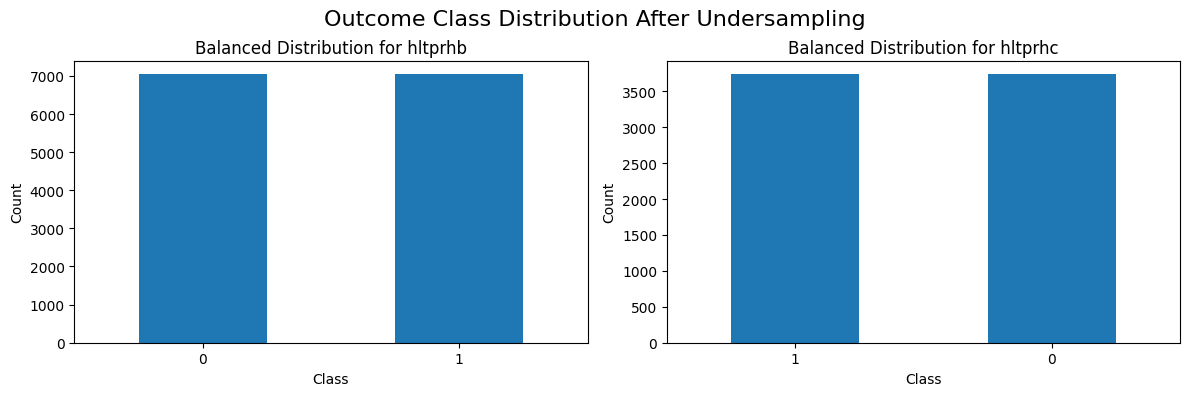

In [9]:
import matplotlib.pyplot as plt

balanced_dfs = {
    "hltprhb": balanced_hb,
    "hltprhc": balanced_hc
}

fig, axes = plt.subplots(1, len(balanced_dfs), figsize=(12, 4))

for ax, (col, df) in zip(axes, balanced_dfs.items()):
    df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    ax.set_title(f"Balanced Distribution for {col}")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

fig.suptitle("Outcome Class Distribution After Undersampling", fontsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


# balansed single-target csv files

In [11]:
out_dir = DATA_DIR / "06_balanced_target"
out_dir.mkdir(parents=True, exist_ok=True)

balanced_hb.to_csv(out_dir / "balanced_ready_hltprhb_train.csv", index=False)
balanced_hc.to_csv(out_dir / "balanced_ready_hltprhc_train.csv", index=False)